In [451]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sys

Contrastive learning dataset info: 
- columns 0-255 are the latent features of the contrastive model
- location gives a unique id for each 512x512 patch of the image (stitched FOVs) that is consistent across time (54 locations)
- time is the index into the movie (0 to 576, units 5 minutes)

Original endothelial cell dataset info:
- flow rate of 20 dyn/cm^2 from 0 to 24 hours
- flow rate of 6 dyn/cm^2 from 24 to 48 hours
- time interval between images (data points) is 5 minutes

In [300]:
path_to_data = "//allen/aics/assay-dev/users/Benji/CurrentProjects/im2im_dev/cyto-dl/outputs/2024-07-05/15-16-35/predictions.csv"
df = pd.read_csv(path_to_data)
df = df.sort_values(by=['location','time'])
df.head()

,0,1,2,3,4,5,6,7,8,9,...,248,249,250,251,252,253,254,255,location,time
31104,-89.20,44.34,0.3389,81.700,78.44,28.330,-35.47,-3.9750,-25.170,-7.758,...,5.59,-30.62,-1.97,-21.10,38.10,-21.840,33.060,9.63,0,0
31050,-104.60,23.52,-3.9060,57.700,67.44,34.900,-50.84,-6.3950,-22.340,23.190,...,27.03,-24.97,-15.66,-15.31,72.90,3.863,42.700,11.37,0,1
30996,-104.70,8.00,-18.6200,36.400,85.80,6.900,-70.60,0.2363,-13.470,48.380,...,43.38,-44.20,-39.72,-33.30,97.94,26.200,32.530,-25.22,0,2
30942,-71.00,24.50,11.9000,-11.055,102.94,12.234,-56.53,18.5800,-12.125,60.030,...,60.84,-35.40,-76.00,-54.94,79.56,27.280,-5.016,-68.90,0,3
30888,-37.56,47.50,51.7000,-35.800,156.90,7.400,-41.60,26.4700,12.620,37.940,...,94.60,-49.10,-108.25,-87.00,28.77,44.100,-83.100,-159.80,0,4


In [301]:
X = df[df.columns[~df.columns.isin(['location','time'])]].values # remove location and time columns, just get points in feature space
scaler = StandardScaler().fit(X)
X = (X-scaler.mean_)/scaler.scale_ 

In [302]:
data_scaled = np.hstack((X,df['location'].values[:,None],df['time'].values[:,None]))
df_scaled = pd.DataFrame(data_scaled, columns=df.columns)
df_scaled['location'] = df_scaled['location'].astype(int)
df_scaled['time'] = df_scaled['time'].astype(int)
df_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,248,249,250,251,252,253,254,255,location,time
0,-0.973683,0.386795,0.009499,0.832618,0.889411,0.346737,-0.565339,-0.061267,-0.301380,-0.177065,...,0.225949,-0.373991,-0.061452,-0.332277,0.415217,-0.258193,0.518083,0.162392,0,0
1,-1.156237,0.149014,-0.052392,0.581020,0.766537,0.436541,-0.855732,-0.090928,-0.262703,0.263185,...,0.540953,-0.308445,-0.198098,-0.262084,0.797005,0.081767,0.649572,0.182431,0,1
2,-1.157422,-0.028236,-0.266923,0.357727,0.971625,0.053814,-1.229066,-0.009652,-0.141477,0.621524,...,0.781173,-0.531535,-0.438250,-0.480180,1.071717,0.377206,0.510854,-0.238965,0,2
3,-0.757937,0.160207,0.178060,-0.139756,1.163086,0.126723,-0.963235,0.215175,-0.123095,0.787250,...,1.037702,-0.429445,-0.800375,-0.742525,0.870071,0.391491,-0.001271,-0.742015,0,3
4,-0.361533,0.422885,0.758345,-0.399164,1.765840,0.060648,-0.681156,0.311877,0.215095,0.473010,...,1.533716,-0.588380,-1.122275,-1.131195,0.312859,0.613960,-1.066333,-1.788882,0,4


Number of modes to explain 95% of variance:  14


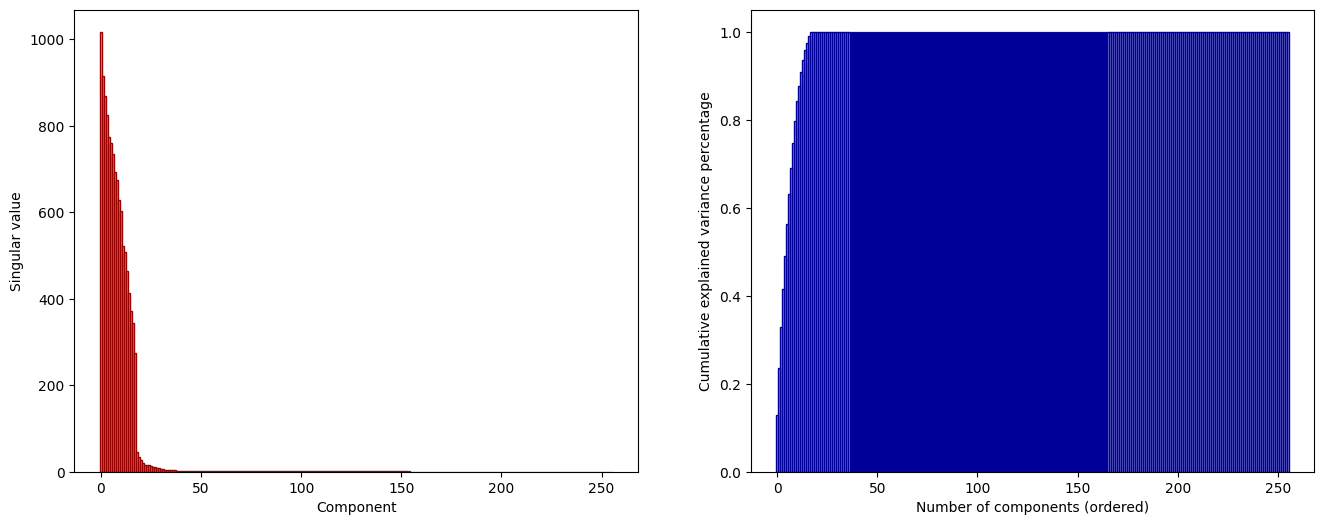

In [303]:
pcaFull = PCA().fit(X) # PCA on scaled contrastive learning features

fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].bar(np.arange(X.shape[1]),pcaFull.singular_values_, color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(X.shape[1]),np.cumsum(pcaFull.explained_variance_ratio_),color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

num_modes_95 = np.where(np.cumsum(pcaFull.explained_variance_ratio_) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Text(0, 0.5, 'Cumulative explained variance percentage')

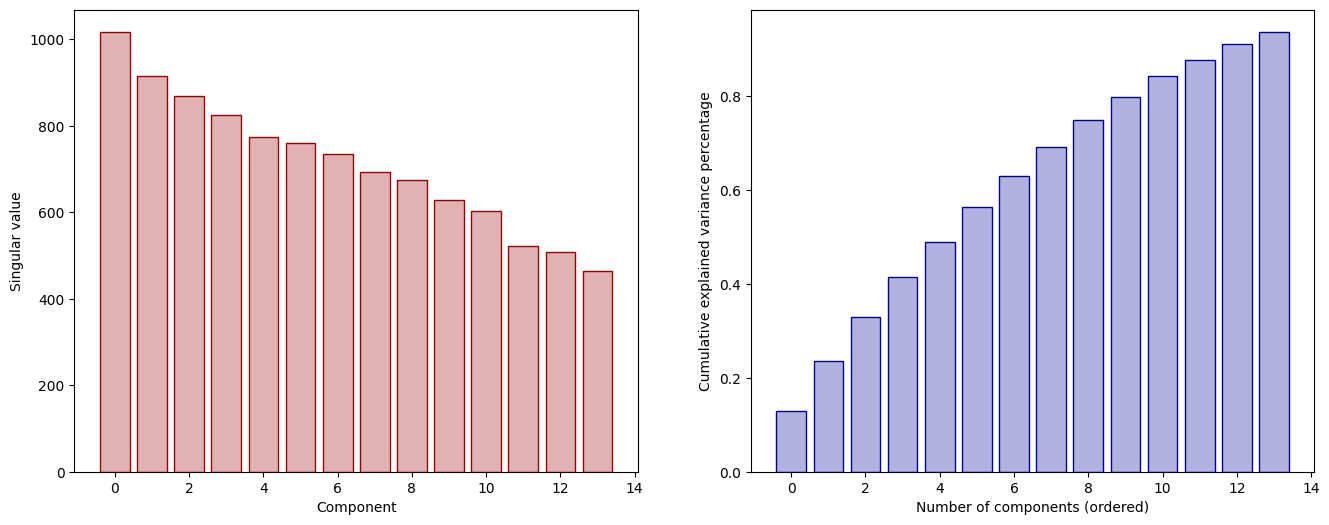

In [304]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].bar(np.arange(num_modes_95),pcaFull.singular_values_[:num_modes_95], color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(num_modes_95),np.cumsum(pcaFull.explained_variance_ratio_)[:num_modes_95],color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

In [305]:
pca2D = PCA(n_components=2).fit(X)
W_2D = pca2D.components_.T # in data matrix X, each column is a feature, each row is a data point: take transpose of projection matrix, right multiply
X_pca = X@W_2D # project data into 2D (each point is a row vector)

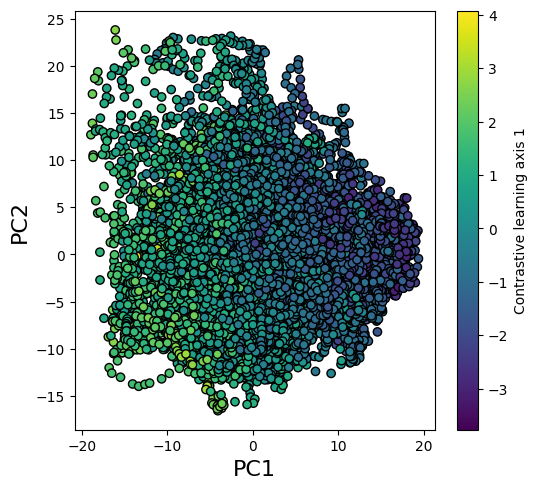

In [306]:
idx = 0 # color each point by value of contrastive learning feature idx
fig, ax = plt.subplots(1,1, figsize=(5.5,5))
sc_plt = ax.scatter(X_pca[:,0], X_pca[:,1],c=X[:,idx],edgecolor=(0.0,0.0,0.0,1.0)) 
plt.colorbar(sc_plt,label='Contrastive learning axis '+str(idx+1), ax=ax)
ax.set_xlabel("PC1", fontsize=16)
ax.set_ylabel("PC2", fontsize=16)
plt.tight_layout()

In [307]:
loc_traj = []
loc_traj_2D = []
loc_traj_PCA = []
pcaND = PCA(n_components=num_modes_95).fit(X) # PCA on scaled contrastive learning features, keep top modes for 95% of variance
W_ND = pcaND.components_.T # in data matrix X, each column is a feature, each row is a data point: take transpose of projection matrix, right multiply
for loc in df_scaled.location.unique():
    loc_df = df_scaled[df_scaled.location == loc]
    traj = loc_df[loc_df.columns[~loc_df.columns.isin(['location','time'])]].values # get scaled contrastive learning features over time for this location
    loc_traj.append(traj)
    loc_traj_2D.append(traj@W_2D) # project trajectory into 2D
    loc_traj_PCA.append(traj@W_ND) # project trajectory into top modes for 95% of variance

### Split data into high vs. low flow

In [308]:
high_flow = np.linspace(0,24*60//5,24*60//5).astype(int) # timepoints with high flow
low_flow = np.linspace(24*60//5,48*60//5,24*60//5).astype(int) # timepoints with low flow

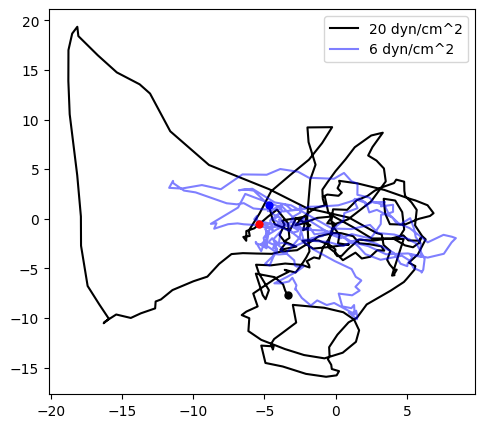

In [309]:
loc_idx = 10 # location index
my_traj = loc_traj_2D[loc_idx]

plt.figure(figsize=(5.5,5))

plt.plot(my_traj[np.concatenate(high_flow,low_flow[0]),0],my_traj[np.concatenate(high_flow,low_flow[0]),1],color=(0.0,0.0,0.0,1.0), label='20 dyn/cm^2')
plt.plot(my_traj[low_flow,0],my_traj[low_flow,1],color=(0.0,0.0,1.0,0.5), label='6 dyn/cm^2')

plt.plot(my_traj[0,0],my_traj[0,1],'k.',markersize=10) # initial point
plt.plot(my_traj[low_flow[0],0],my_traj[low_flow[0],1],'b.',markersize=10) # point at start of low flow
plt.plot(my_traj[-1,0],my_traj[-1,1],'r.',markersize=10) # final point
plt.legend()

To deal with fact that location =/= single cell over long time span, break each trajectory into short "sub-trajectories" of length 4 time points that ~ correspond to one cell's features over that time window.

In [310]:
high_flow_short_traj = []
low_flow_short_traj = []
for traj in loc_traj:
    high_flow_split = np.split(traj[high_flow],len(high_flow)//4)
    low_flow_split = np.split(traj[low_flow],len(low_flow)//4)
    high_flow_short_traj.extend(high_flow_split)
    low_flow_short_traj.extend(low_flow_split)
        

In [378]:
X_t = np.array(loc_traj_PCA) # full trajectories for all locations, all times
X_t_high = X_t[:,high_flow,:] # full high flow trajectories (i.e., features per location over all time)
X_t_low = X_t[:,low_flow,:] # full low flow trajectories

## SparseVFC vector field learning

In [311]:
sys.path.append('//allen/aics/assay-dev/users/Erin/cell-state/git-repos/hcs-data-analysis/pycode')

# import code from pycode directory in hcs-data-analysis repository
import sparseVFC as svfc
from get_dX import *
from vecField_2D import *
import pplane as pplane

from sklearn.model_selection import train_test_split


In [312]:
dt = 1/6 # start by units 5/dt minutes

# get velocity vectors for each trajectory, again putting np.nan where data are missing and/or dx/dt cannot be estimated
dX_high = get_dX(X_t_high,dt) 
dX_low = get_dX(X_t_low,dt)

# now, build arrays of X (points along single cell trajectories) and corresponding Y = dX/dt|_X: dim is sum(num_non_nan_timepoints per trajectory) x num_feats
X_high,Y_high = build_XY(X_t_high, dX_high)
X_low,Y_low = build_XY(X_t_low, dX_low)

In [313]:
# build training and test sets
N_tot_high = X_high.shape[0]
N_train_high=int(0.8*N_tot_high) # 80% of data for training
N_test_high = N_tot_high-N_train_high

X_train_high, X_test_high, Y_train_high, Y_test_high = train_test_split(X_high, Y_high, test_size=N_test_high, random_state=1)

# build training and test sets
N_tot_low = X_low.shape[0]
N_train_low=int(0.8*N_tot_low) # 80% of data for training
N_test_low = N_tot_low-N_train_low

X_train_low, X_test_low, Y_train_low, Y_test_low = train_test_split(X_low, Y_low, test_size=N_test_high, random_state=1)

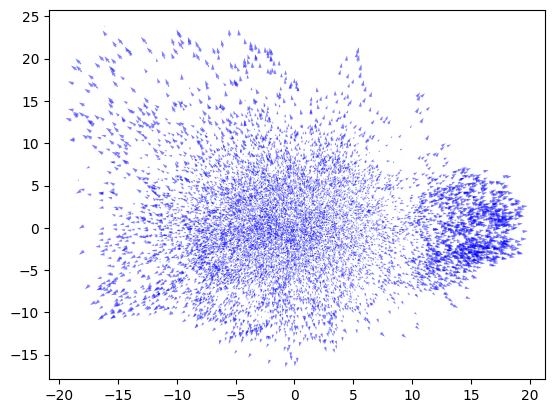

In [314]:
plt.quiver(X_high[:,0],X_high[:,1],Y_high[:,0],Y_high[:,1],color='b',alpha=0.5) # plot high flow veolcity vectors in top two PCA space

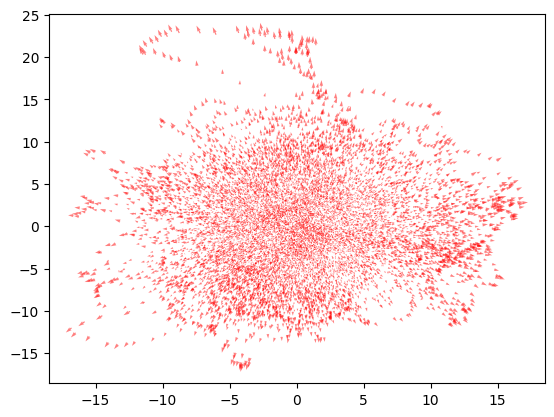

In [315]:
plt.quiver(X_low[:,0],X_low[:,1],Y_low[:,0],Y_low[:,1],color='r',alpha=0.5) # plot low flow veolcity vectors in top two PCA space

##### Model training

In [316]:
(X_train_high.max()-X_train_high.min())**14

6.782009297742749e+22

In [317]:
svfc_model = svfc.SparseVFC(kernel='rbf',theta=0.7,lam=0.0,M=1000).fit(X_train_high,Y_train_high)

inlier_idx = svfc_model.inliers_

R2_rbf_test = svfc_model.score(X_test_high,Y_test_high)

# paper suggests using metric standard deviation of inlier set instead of MSE
if len(inlier_idx) == 0:
    stdev_rbf_inliers = np.nan
else:
    stdev_rbf_inliers = np.sqrt((1/len(inlier_idx))*np.sum(np.linalg.norm(svfc_model.predict(X_train_high[inlier_idx,:])-Y_train_high[inlier_idx,:],axis=1)**2))

print("Number of inlier points identified by SparseVFC algorithm: ",len(inlier_idx))
print('Coefficient of determination (R^2) of RBF kernel model on test set: %f' %R2_rbf_test)
print('Standard deviation of RBF kernel model on training set inliers: %f' %stdev_rbf_inliers)

Number of inlier points identified by SparseVFC algorithm:  0
Coefficient of determination (R^2) of RBF kernel model on test set: 0.073273
Standard deviation of RBF kernel model on training set inliers: nan


In [318]:
# data already along PC components
# so projection matrix to top 2 pc components is just the (num_modes_95)x2 matrix [e_0 e_1]
W = np.column_stack((np.eye(num_modes_95)[0,:],np.eye(num_modes_95)[1,:]))
svfc_model.project2D(W) # projects coefficent vectors into 2D (each coefficient vector is a row vector)
X_high_pca = X_high@W # project data into 2D (each point is a row vector)
X_low_pca = X_low@W

In [319]:
xlim = [-25,25]
ylim = [-25,25]
N_mesh = 40
U1,U2 = np.meshgrid(np.linspace(xlim[0],xlim[1],N_mesh),np.linspace(ylim[0],ylim[1],N_mesh))
V = svfc_model.predict_2D_mesh([U1,U2])

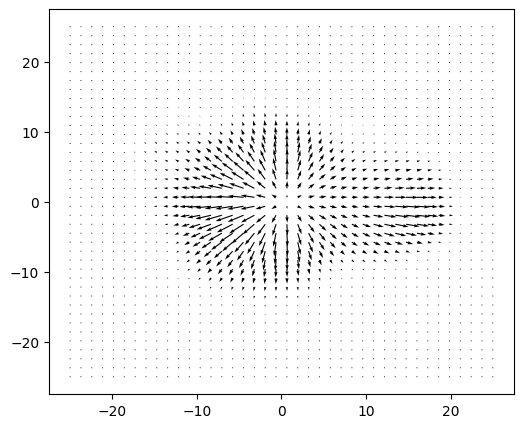

In [320]:
fig,ax = plot_vector_field(U1,U2,V,scale=27000)

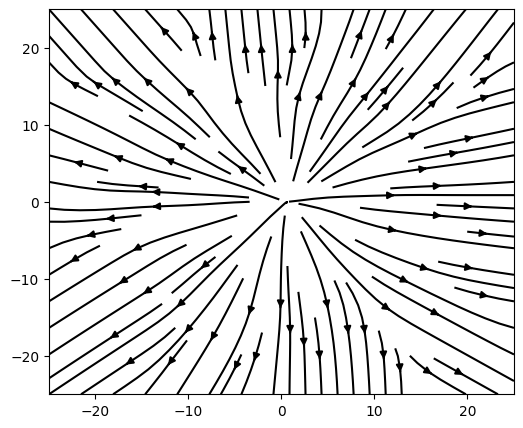

In [321]:
fig,ax = plot_vector_field(U1,U2,V,stream=True)

In [322]:
def f(X1,X2,svfc_2D):
    if not hasattr(svfc_2D,'proj_'): 
        svfc_2D.project2D(np.eye(2))
    if X1.ndim == 2:
        return np.swapaxes(svfc_2D.predict_2D_mesh([X1,X2]),0,1).T
    else:
        return svfc_2D.predict_2D(np.array([X1,X2]))[0]

def f1(x1,x2):
    return f(x1,x2,svfc_model)[0]

def f2(x1,x2):
    return f(x1,x2,svfc_model)[1]

Fixed points:
  • Unstable node at x = (0.565,-0.019)


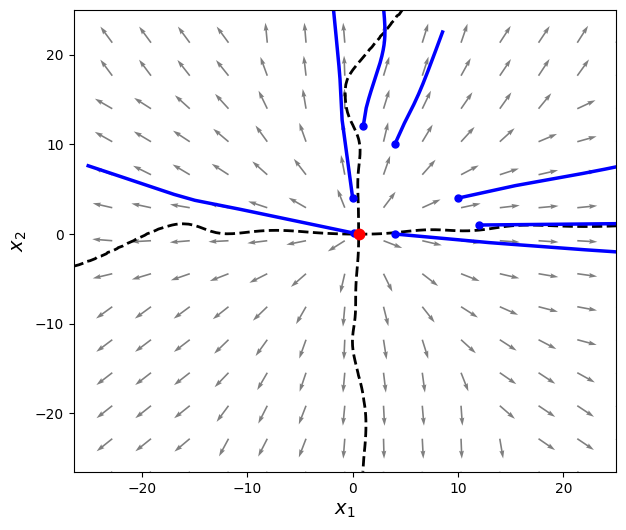

In [323]:
inits = [(0.1,0.1),(0,4),(4,0),(4,10),(10,4),(1,12),(12,1)]
timeVec = np.linspace(0, 20, 1000)
x1vec = np.linspace(xlim[0]-1.5,xlim[1],100)
x2vec = np.linspace(ylim[0]-1.5,ylim[1],100)
fig = pplane.plot_portrait(f1,f2,x1vec,x2vec,timeVec,inits)

## Langevin regression (1D)

In [324]:
import sympy

sys.path.append('//allen/aics/assay-dev/users/Erin/cell-state/git-repos/langevin-regression')

# import SINDY for Langevin
import utils
import fpsolve

def KM_avg(X, bins, stride, dt, multi_traj=False):
    if multi_traj:
        n = len(X)
        f_KM = np.zeros((len(bins)-1,n))
        a_KM = np.zeros(f_KM.shape)
        f_err = np.zeros(f_KM.shape)
        a_err = np.zeros(f_KM.shape)
        for (j,traj) in enumerate(X):
            Y = traj[::stride] 
            tau = stride*dt
            dY = (Y[1:] - Y[:-1])/tau  # Step (like a finite-difference derivative estimate)
            dY2 = (Y[1:] - Y[:-1])**2/tau
        
            # At each histogram bin, find time series points where the state falls into this bin
            for i in range(len(bins)-1):
                mask = np.nonzero( (Y[:-1] > bins[i]) * (Y[:-1] < bins[i+1]) )[0]

                if len(mask) > 0:
                    f_KM[i,j] = np.mean(dY[mask]) # Conditional average  ~ drift
                    a_KM[i,j] = 0.5*np.mean(dY2[mask]) # Conditional variance  ~ diffusion

                    # Estimate error by variance of samples in the bin
                    a_KM[i,j] = 0.5*np.mean(dY2[mask]) # Conditional average
                    a_err[i,j] = np.std(dY2[mask])/np.sqrt(len(mask))

                else:
                    f_KM[i,j] = np.nan
                    f_err[i,j] = np.nan
                    a_KM[i,j] = np.nan
                    a_err[i,j] = np.nan
        f_KM = np.nanmean(f_KM,axis=1)
        a_KM = np.nanmean(a_KM,axis=1)
        f_err = np.nanmean(f_err,axis=1)
        a_err = np.nanmean(a_err,axis=1)
#####################
    else:
        Y = X[::stride] 
        tau = stride*dt
        dY = (Y[1:] - Y[:-1])/tau  # Step (like a finite-difference derivative estimate)
        dY2 = (Y[1:] - Y[:-1])**2/tau  # Conditional variance
        
        f_KM = np.zeros(len(bins)-1)
        a_KM = np.zeros(f_KM.shape)
        f_err = np.zeros(f_KM.shape)
        a_err = np.zeros(f_KM.shape)
    
        # At each histogram bin, find time series points where the state falls into this bin
        for i in range(len(bins)-1):
            mask = np.nonzero( (Y[:-1] > bins[i]) * (Y[:-1] < bins[i+1]) )[0]

            if len(mask) > 0:
                f_KM[i] = np.mean(dY[mask]) # Conditional average  ~ drift
                a_KM[i] = 0.5*np.mean(dY2[mask]) # Conditional variance  ~ diffusion

                # Estimate error by variance of samples in the bin
                a_KM[i] = 0.5*np.mean(dY2[mask]) # Conditional average
                a_err[i] = np.std(dY2[mask])/np.sqrt(len(mask))

            else:
                f_KM[i] = np.nan
                f_err[i] = np.nan
                a_KM[i] = np.nan
                a_err[i] = np.nan
            
    return f_KM, a_KM, f_err, a_err



def cost(Xi, params):
    """
    Least-squares cost function for optimization
    This version is only good in 1D, but could be extended pretty easily
    Xi - current coefficient estimates
    param - inputs to optimization problem: grid points, list of candidate expressions, regularizations
        W, f_KM, a_KM, x_pts, y_pts, x_msh, y_msh, f_expr, a_expr, l1_reg, l2_reg, kl_reg, p_hist, etc
    """
    
    # Unpack parameters
    W = params['W']  # Optimization weights
    
    # Kramers-Moyal coefficients
    f_KM, a_KM = params['f_KM'].flatten(), params['a_KM'].flatten()
    
    fp, afp = params['fp'], params['afp'] # Fokker-Planck solvers
    lib_f, lib_s = params['lib_f'], params['lib_s']
    N = params['N']
    
    # Construct parameterized drift and diffusion functions from libraries and current coefficients
    f_vals = lib_f @ Xi[:lib_f.shape[1]]
    a_vals = 0.5*(lib_s @ Xi[lib_f.shape[1]:])**2
        
    # Solve AFP equation to find finite-time corrected drift/diffusion
    #    corresponding to the current parameters Xi
    afp.precompute_operator(np.reshape(f_vals, N), np.reshape(a_vals, N))
    f_tau, a_tau = afp.solve(params['tau'])
            
    # Histogram points without data have NaN values in K-M average - ignore these in the average
    mask = np.nonzero(np.isfinite(f_KM))[0]
    V = np.sum(W[0, mask]*abs(f_tau[mask] - f_KM[mask])**2) \
      + np.sum(W[1, mask]*abs(a_tau[mask] - a_KM[mask])**2)
    
    # Include PDF constraint via Kullbeck-Leibler divergence regularization
    if params['kl_reg'] > 0:
        p_hist = params['p_hist']  # Empirical PDF
        p_est = fp.solve(f_vals, a_vals)  # Solve Fokker-Planck equation for steady-state PDF
        kl = utils.kl_divergence(p_hist, p_est, dx=fp.dx, tol=1e-6)
        kl = max(0, kl)  # Numerical integration can occasionally produce small negative values
        V += params['kl_reg']*kl
    return V

In [382]:
X_t_full = np.array(loc_traj) # full trajectories for all locations, all times
X_t = np.array(loc_traj_PCA) # full trajectories for all locations, all times (top PCA modes for 95% of variance)
X_t_high = X_t[:,high_flow,:] # full high flow trajectories (i.e., features per location over all time)
X_t_low = X_t[:,low_flow,:] # full low flow trajectories
num_loc = X_t.shape[0]
num_t = X_t.shape[1]
num_feats = X_t_full.shape[-1]
dt = 5 # units 5/dt minutes

Text(0, 0.5, 'PC1')

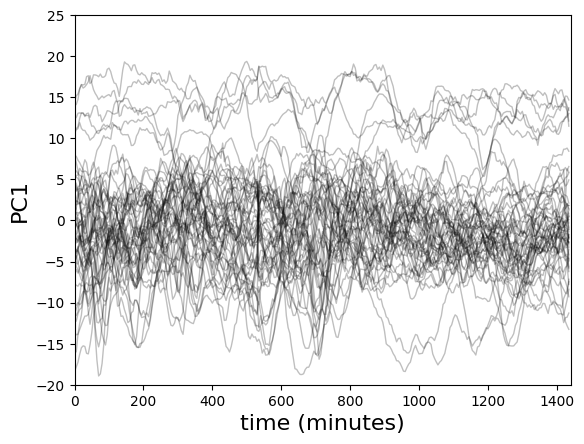

In [326]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t//2),X_t_high[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,X_t_high.shape[1]*5])
plt.ylim([-20,25])
plt.xlabel("time (minutes)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC1')

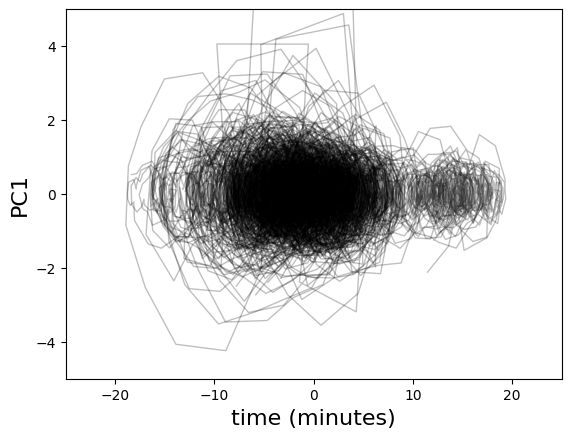

In [486]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(X_t_high[i,:,0],np.gradient(X_t_high[i,:,0]),'k-',alpha=0.25,linewidth=1)
plt.xlim([-25,25])
plt.ylim([-5,5])
plt.xlabel("time (minutes)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC1')

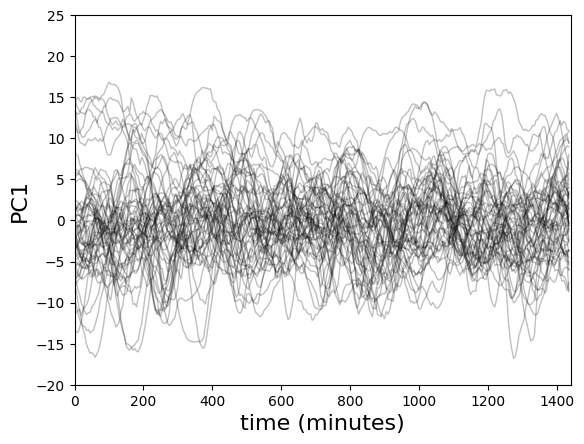

In [327]:
# plot top PCA mode vs derivative for each location at low flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t//2),X_t_low[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,X_t_low.shape[1]*5])
plt.ylim([-20,25])
plt.xlabel("time (minutes)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC1')

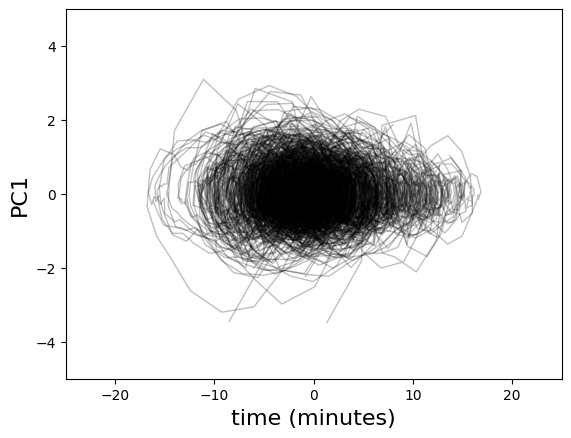

In [485]:
# plot top PCA mode vs derivative for each location at high flow
for i in range(num_loc):
    plt.plot(X_t_low[i,:,0],np.gradient(X_t_low[i,:,0]),'k-',alpha=0.25,linewidth=1)
plt.xlim([-25,25])
plt.ylim([-5,5])
plt.xlabel("time (minutes)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

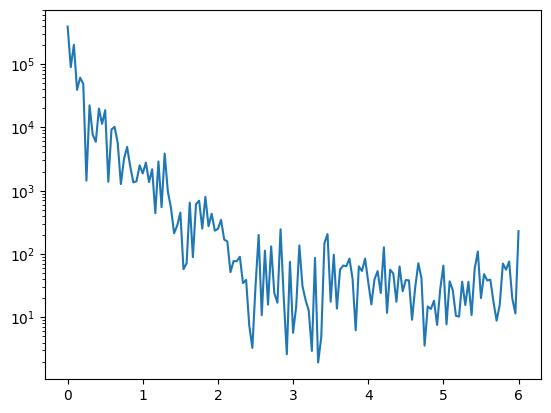

Peak frequency:  0.0833  (hours)^(-1)
Corresponding period:  12.0  hours


In [468]:
loc_idx=3
test_traj = X_t_high[loc_idx,:,0]
ps = np.abs(np.fft.rfft(test_traj))**2

fs = 12 # time unit = 1 hour, get 1 sample every 5 minutes, so 12 samples per hour
freqs = np.linspace(0,fs/2,ps.size)

plt.semilogy(freqs, ps)
plt.show()

print("Peak frequency: ", freqs[np.argmax(ps[1:])+1].round(4), " (hours)^(-1)")
print("Corresponding period: ", 1/freqs[np.argmax(ps[1:])+1], " hours")

In [470]:
max_freqs = np.zeros(num_loc)
for loc_idx in range(num_loc):
    traj = X_t_high[loc_idx,:,0]
    ps = np.abs(np.fft.rfft(traj))**2
    fs = 12 # time unit = 1 hour, get 1 sample every 5 minutes, so 12 samples per hour
    freqs = np.linspace(0,fs/2,ps.size)
    max_freqs[loc_idx] = freqs[np.argmax(ps[1:])+1]

print("Average peak frequency: ", np.mean(max_freqs).round(4), " (hours)^(-1)")
print("Corresponding average period: ", (1/np.mean(max_freqs)).round(4), " hours",'\n')

print("Median peak frequency: ", np.median(max_freqs).round(4), " (hours)^(-1)")
print("Corresponding median period: ", (1/np.median(max_freqs)).round(4), " hours")

Average peak frequency:  0.1096  (hours)^(-1)
Corresponding average period:  9.1268  hours 

Median peak frequency:  0.0833  (hours)^(-1)
Corresponding median period:  12.0  hours


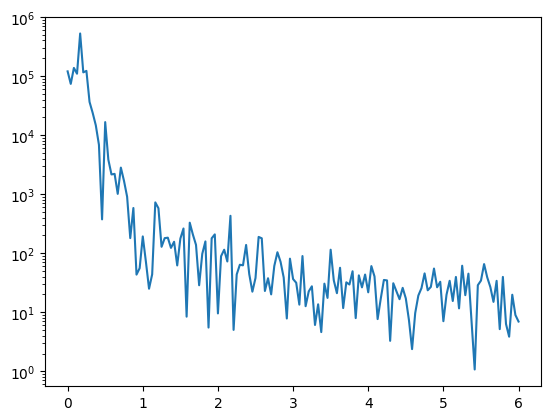

Peak frequency:  0.1667  (hours)^(-1)
Corresponding period:  6.0  hours


In [471]:
loc_idx=0
test_traj = X_t_low[loc_idx,:,0]
ps = np.abs(np.fft.rfft(test_traj))**2

fs = 12 # time unit = 1 hour, get 1 sample every 5 minutes, so 12 samples per hour
freqs = np.linspace(0,fs/2,ps.size)

plt.semilogy(freqs, ps)
plt.show()
print("Peak frequency: ", freqs[np.argmax(ps)].round(4), " (hours)^(-1)")
print("Corresponding period: ", 1/freqs[np.argmax(ps)], " hours")

In [472]:
max_freqs = np.zeros(num_loc)
for loc_idx in range(num_loc):
    traj = X_t_low[loc_idx,:,0]
    ps = np.abs(np.fft.rfft(traj))**2
    fs = 12 # time unit = 1 hour, get 1 sample every 5 minutes, so 12 samples per hour
    freqs = np.linspace(0,fs/2,ps.size)
    max_freqs[loc_idx] = freqs[np.argmax(ps[1:])+1]

print("Average peak frequency: ", np.mean(max_freqs).round(4), " (hours)^(-1)")
print("Corresponding average period: ", (1/np.mean(max_freqs)).round(4), " hours",'\n')

print("Median peak frequency: ", np.median(max_freqs).round(4), " (hours)^(-1)")
print("Corresponding median period: ", (1/np.median(max_freqs)).round(4), " hours")

Average peak frequency:  0.1582  (hours)^(-1)
Corresponding average period:  6.322  hours 

Median peak frequency:  0.1667  (hours)^(-1)
Corresponding median period:  6.0  hours


### High flow trajectories

/tmp/ipykernel_9299/156247817.py:39: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=1)
/tmp/ipykernel_9299/156247817.py:40: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=1)
/tmp/ipykernel_9299/156247817.py:41: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=1)
/tmp/ipykernel_9299/156247817.py:42: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=1)


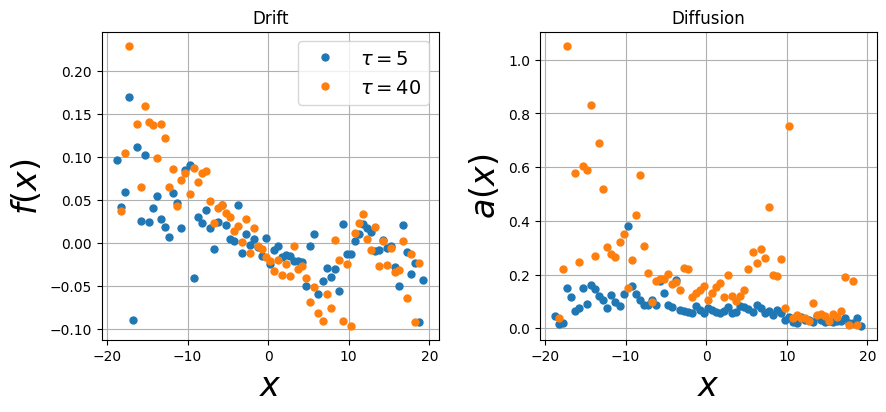

In [ ]:
# Langevin regression on first PC mode

# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

N = 100 # Number of bins
bins = np.linspace(-25,25, N+1)
dx = bins[1]-bins[0]
centers = (bins[:-1]+bins[1:])/2

data = [X_t_high[i,:,0] for i in range(num_loc)] # high flow data, pass as list into KM_avg

f_fine, a_fine, _,_ = KM_avg(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=8
f_coarse, a_coarse, _,_ = KM_avg(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(centers, f_fine, '.', markersize=10, c=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.plot(centers, f_coarse, '.', markersize=10, c=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.plot(centers, a_fine, '.', c=colors[0], markersize=10)
plt.plot(centers, a_coarse, '.', c=colors[1], markersize=10)
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

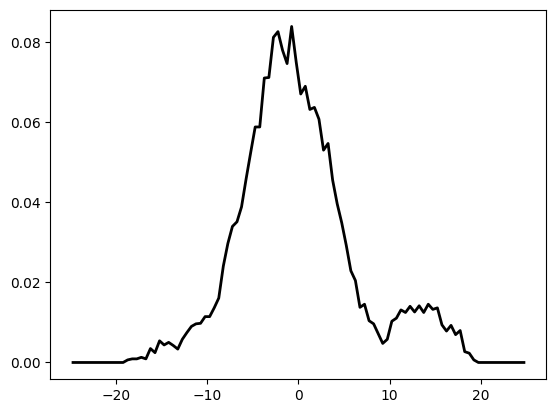

In [ ]:
# PDF of states

p_hist = np.histogram(np.concatenate(data), bins, density=True)[0]
plt.plot(centers, p_hist, 'k', lw=2)

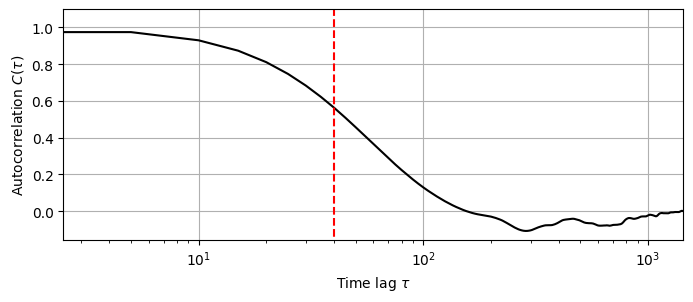

In [ ]:
tau = dt*np.arange(0, len(data[0]))
acf = np.zeros(len(tau))
for loc_idx in range(num_loc):
    acf = acf + utils.autocorr_func_1d(data[loc_idx])
acf = acf/num_loc

plt.figure(figsize=(8, 3))
plt.plot(tau, acf, 'k')

plt.ylabel(r'Autocorrelation $C(\tau)$')
plt.xlabel(r'Time lag $\tau$')
plt.vlines(stride_coarse*dt, -0.6, 1.1, 'r', '--')

plt.ylim([acf.min()-0.05, 1.1])
plt.xlim([0.5*dt, tau.max()])
plt.gca().set_xscale('log')

plt.grid()
plt.show()


/home/erin.angelini/my-envs/hcs-env/lib/python3.11/site-packages/numpy/lib/histograms.py:1067: RuntimeWarning: invalid value encountered in divide
  hist /= s
/home/erin.angelini/my-envs/hcs-env/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


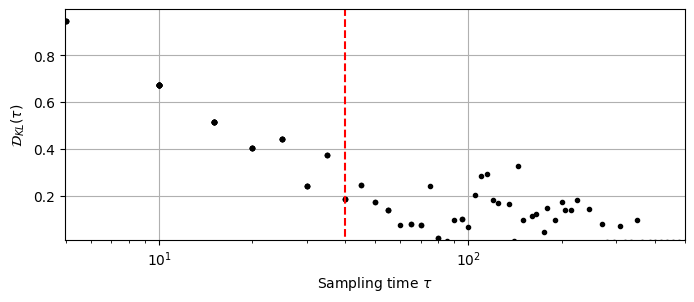

In [ ]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([utils.markov_test(data[loc_idx], delta, N=32) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, kl_div.max()+0.05])
plt.grid()

In [ ]:
## Kramers-Moyal average
stride = stride_coarse
f_KM, a_KM, f_err, a_err = KM_avg(data, bins, stride=stride, dt=dt, multi_traj=True)

/tmp/ipykernel_9299/156247817.py:39: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=1)
/tmp/ipykernel_9299/156247817.py:40: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=1)
/tmp/ipykernel_9299/156247817.py:41: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=1)
/tmp/ipykernel_9299/156247817.py:42: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=1)


In [ ]:
### Build SINDy libraries with sympy
x = sympy.symbols('x')

f_expr = np.array([x**i for i in np.arange(5)])  # Polynomial library for drift
s_expr = np.array([x**i for i in np.arange(4)])  # Polynomial library for diffusion

# Convert sympy expressions into library matrices
lib_f = np.zeros([len(f_expr), N])
for k in range(len(f_expr)):
    lamb_expr = sympy.lambdify(x, f_expr[k])
    lib_f[k] = lamb_expr(centers)

lib_s = np.zeros([len(s_expr), N])
for k in range(len(s_expr)):
    lamb_expr = sympy.lambdify(x, s_expr[k])
    lib_s[k] = lamb_expr(centers)

In [ ]:
# Initialize Xi with least squares regression (no finite-time corrections)

Xi0 = np.zeros((len(f_expr) + len(s_expr)))
mask = np.nonzero(np.isfinite(f_KM))[0]
Xi0[:len(f_expr)] = np.linalg.lstsq( lib_f[:, mask].T, f_KM[mask], rcond=None)[0]   # Regression against drift
Xi0[len(f_expr):] = np.linalg.lstsq( lib_s[:,mask].T, np.sqrt(2*a_KM[mask]), rcond=None)[0]  # Regression against diffusion

print(Xi0)

[-2.30174459e-02 -6.33710620e-03  6.74771822e-04  7.26195454e-06
 -1.50937544e-06  6.18144474e-01 -1.05866843e-02  9.96412217e-05
 -2.60645230e-05]


In [ ]:
### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.flatten(), a_err.flatten()))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())

# Compute empirical PDF
p_hist = np.histogram(np.concatenate(data), bins, density=True)[0]

# Initialize adjoint solver
afp = fpsolve.AdjFP(centers)

# Initialize forward steady-state solver
fp = fpsolve.SteadyFP(N, dx)

# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f.T, "lib_s": lib_s.T, "N": N,
          "kl_reg": 10,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

# Use anonymous function to automatically pass the cost function
opt_fun = lambda params: utils.AFP_opt(cost, params)
Xi, V = utils.SSR_loop(opt_fun, params)

%%%% Optimization time: 16.96815323829651 seconds,   Cost: 0.12548192235031794 %%%%
[1 2 3 4]
[0 1 2 3]
[x x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 30.884563207626343 seconds,   Cost: 0.31313251764811373 %%%%
[0 2 3 4]
[0 1 2 3]
[1 x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 18.72184681892395 seconds,   Cost: 0.022694351001087677 %%%%
[0 1 3 4]
[0 1 2 3]
[1 x x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 12.685444593429565 seconds,   Cost: 0.31979878289026487 %%%%
[0 1 2 4]
[0 1 2 3]
[1 x x**2 x**4] [1 x x**2 x**3]
%%%% Optimization time: 10.240637302398682 seconds,   Cost: 0.13106651928793986 %%%%
[0 1 2 3]
[0 1 2 3]
[1 x x**2 x**3] [1 x x**2 x**3]
%%%% Optimization time: 16.16632318496704 seconds,   Cost: 0.2684730308727861 %%%%
[0 1 2 3 4]
[1 2 3]
[1 x x**2 x**3 x**4] [x x**2 x**3]
%%%% Optimization time: 17.3624370098114 seconds,   Cost: 34.66703157645165 %%%%
[0 1 2 3 4]
[0 2 3]
[1 x x**2 x**3 x**4] [1 x**2 x**3]
%%%% Optimization time: 28.704353570

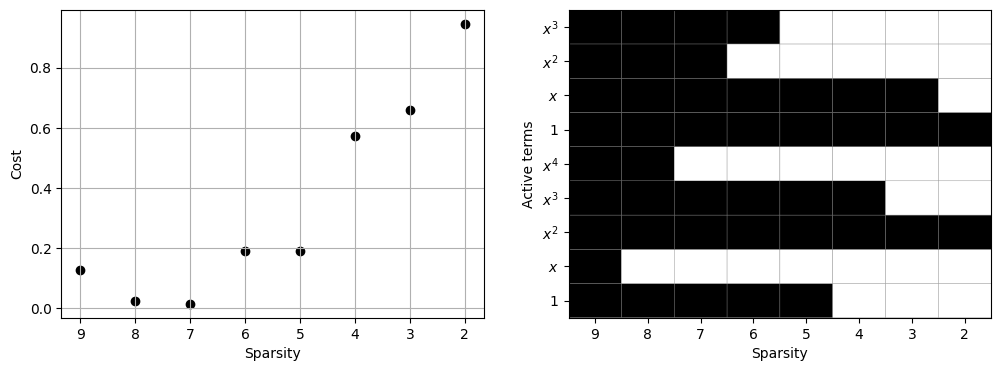

In [ ]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(np.arange(len(V)), V, c='k')

plt.gca().set_xticks(np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
#plt.gca().set_yscale('log')
plt.grid()

plt.subplot(122)
plt.pcolor(active, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(n_terms))
plt.gca().set_yticklabels(labels)
plt.gca().set_xticks(0.5+np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel('Active terms')
plt.show()

In [ ]:
# Select model with the fewest terms before the cost function spikes
n_terms = 5
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V[1-n_terms])
Xi_f = Xi[:len(f_expr), 1-n_terms]
Xi_s = Xi[len(f_expr):, 1-n_terms]
print("Basis functions (drift): ", f_expr)
print("SINDy expression (drift): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f])
print("Base functions (diffusion): ", s_expr)
print("SINDy expression (diffusion): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s])

# Functions from the expressions
f_sindy = sympy.lambdify(x, utils.sindy_model(Xi_f, f_expr))
a_sindy = sympy.lambdify(x, 0.5*utils.sindy_model(Xi_s, s_expr)**2)

f_vals = f_sindy(centers)
a_vals = a_sindy(centers)

# Check if a scalar (happens when library is a constant)
if np.isscalar(a_vals):
    a_vals = a_vals + 0*centers
if np.isscalar(f_vals):
    f_vals = f_vals + 0*centers

Optimal sparsity:  5
Cost at optimal sparsity:  0.19129217517919087
Basis functions (drift):  [1 x x**2 x**3 x**4]
SINDy expression (drift):  ['-1.551E-02', '0', '4.820E-04', '-2.611E-05', '0']
Base functions (diffusion):  [1 x x**2 x**3]
SINDy expression (diffusion):  ['3.261E-01', '-4.188E-02', '0', '0']


KL divergence (LINDy model): 0.01625


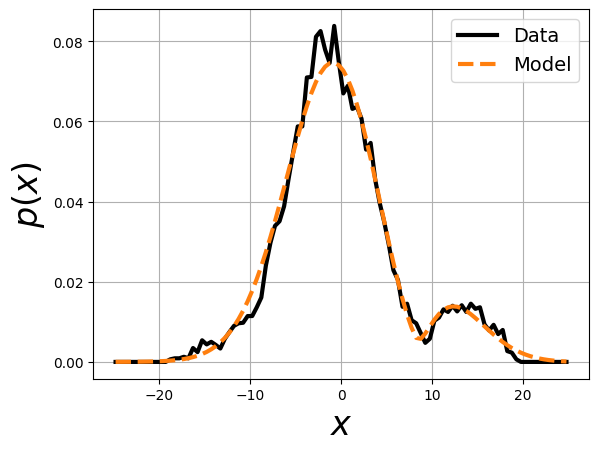

In [ ]:
# Compare PDFs: empirical vs Fokker-Planck solution with model

p_fit = fp.solve(f_vals, a_vals)
print('KL divergence (LINDy model): {0:0.5f}'.format(utils.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

#plt.figure(figsize=(4, 2))
plt.plot(centers, p_hist, 'k', label='Data', lw=3)
plt.plot(centers, p_fit, '--', c=colors[1], label='Model', lw=3)
plt.legend(fontsize=14)
#plt.gca().set_yscale('log')
#plt.xlim([0, 3])
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$p(x)$', fontsize = 24)
plt.grid()

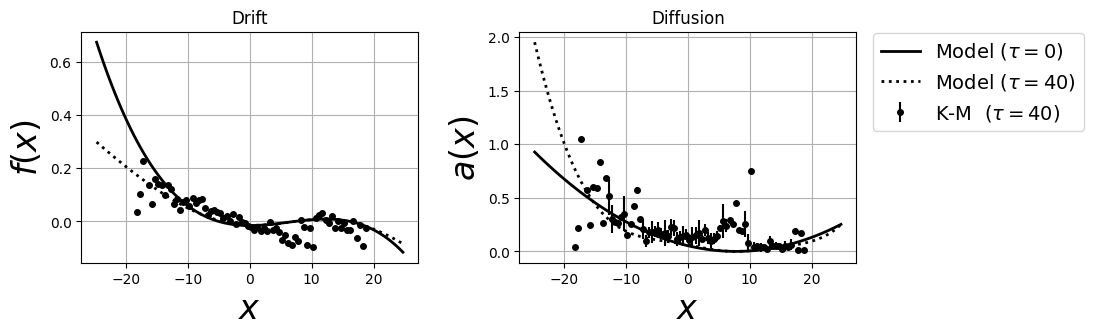

In [ ]:
afp.precompute_operator(f_vals, a_vals)
f_tau, a_tau = afp.solve(stride*dt)

plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.errorbar(centers, f_KM, f_err, ls='', marker='.', markersize=8, 
             c='k')
plt.plot(centers, f_vals, 'k', lw=2)
plt.plot(centers, f_tau, 'k:', lw=2)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()
#plt.xlim([-1.8, 1.8])
#plt.ylim([-1, 0.3])


plt.subplot(122)
plt.errorbar(centers, a_KM, a_err, ls='', marker='.', markersize=8, 
             c='k', label=r'K-M  ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.plot(centers, a_vals, 'k', lw=2, label=r'Model ($\tau = 0$)')
plt.plot(centers, a_tau, 'k:', lw=2, label=r'Model ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()
# plt.xlim([-1.8, 1.8])
#plt.ylim([0, 1.25])

plt.subplots_adjust(wspace=0.3)
plt.show()

Text(0.5, 0, '$x$')

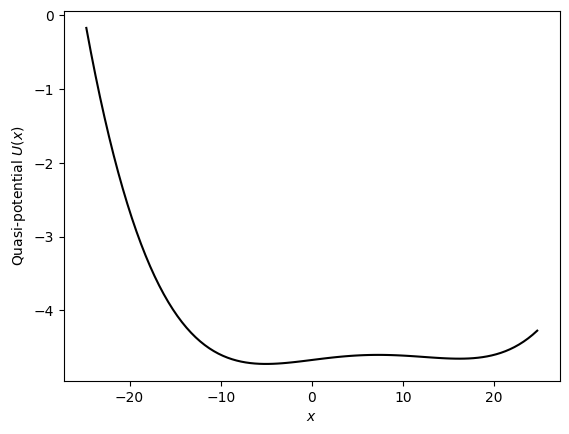

In [ ]:
def U(x):
    h=0.1
    num = np.round((x-bins[0])/h).astype(int)
    xvec = np.linspace(bins[0],x,num)
    return -np.trapz(f_sindy(xvec), xvec)

Uvec = np.zeros(centers.shape[0])
for i in range(centers.shape[0]):
    Uvec[i] = U(centers[i])

plt.plot(centers, Uvec, 'k-')
plt.ylabel('Quasi-potential $U(x)$')
plt.xlabel('$x$')

### Low flow trajectories

/tmp/ipykernel_28078/156247817.py:39: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=1)
/tmp/ipykernel_28078/156247817.py:40: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=1)
/tmp/ipykernel_28078/156247817.py:41: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=1)
/tmp/ipykernel_28078/156247817.py:42: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=1)


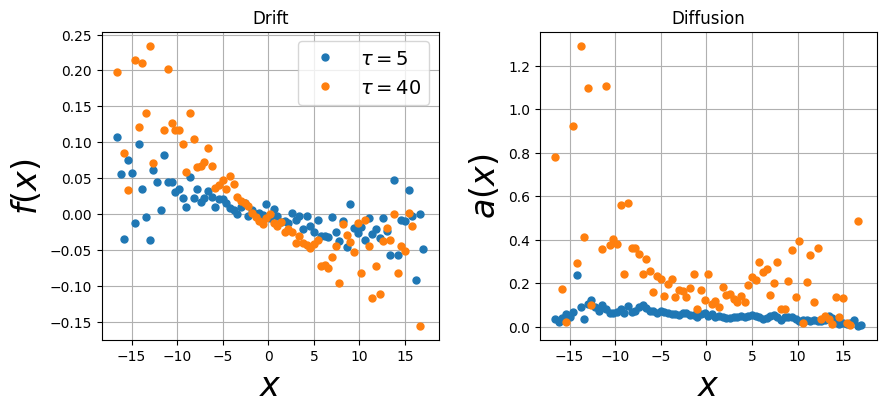

In [ ]:
# Langevin regression on first PC mode

# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

N = 100 # Number of bins
bins = np.linspace(-20,20, N+1)
dx = bins[1]-bins[0]
centers = (bins[:-1]+bins[1:])/2

data = [X_t_low[i,:,0] for i in range(num_loc)] # high flow data, pass as list into KM_avg

f_fine, a_fine, _,_ = KM_avg(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=8
f_coarse, a_coarse, _,_ = KM_avg(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(centers, f_fine, '.', markersize=10, c=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.plot(centers, f_coarse, '.', markersize=10, c=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.plot(centers, a_fine, '.', c=colors[0], markersize=10)
plt.plot(centers, a_coarse, '.', c=colors[1], markersize=10)
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

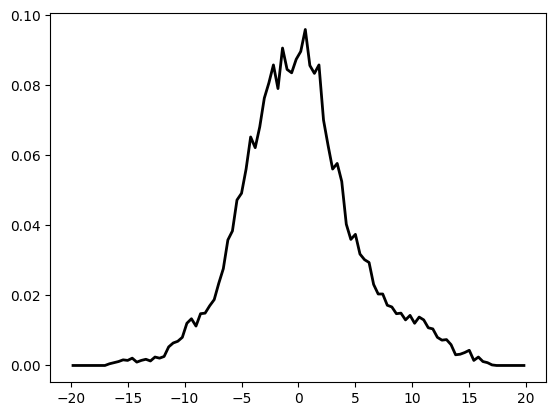

In [ ]:
# PDF of states

p_hist = np.histogram(np.concatenate(data), bins, density=True)[0]
plt.plot(centers, p_hist, 'k', lw=2)

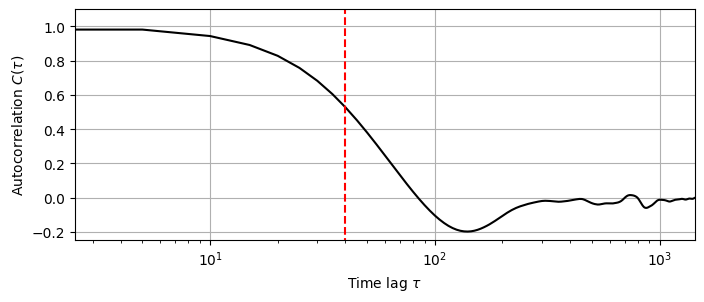

In [ ]:
tau = dt*np.arange(0, len(data[0]))
acf = np.zeros(len(tau))
for loc_idx in range(num_loc):
    acf = acf + utils.autocorr_func_1d(data[loc_idx])
acf = acf/num_loc

plt.figure(figsize=(8, 3))
plt.plot(tau, acf, 'k')

plt.ylabel(r'Autocorrelation $C(\tau)$')
plt.xlabel(r'Time lag $\tau$')
plt.vlines(stride_coarse*dt, -0.6, 1.1, 'r', '--')

plt.ylim([acf.min()-0.05, 1.1])
plt.xlim([0.5*dt, tau.max()])
plt.gca().set_xscale('log')

plt.grid()
plt.show()


/home/erin.angelini/my-envs/hcs-env/lib/python3.11/site-packages/numpy/lib/histograms.py:1067: RuntimeWarning: invalid value encountered in divide
  hist /= s
/home/erin.angelini/my-envs/hcs-env/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


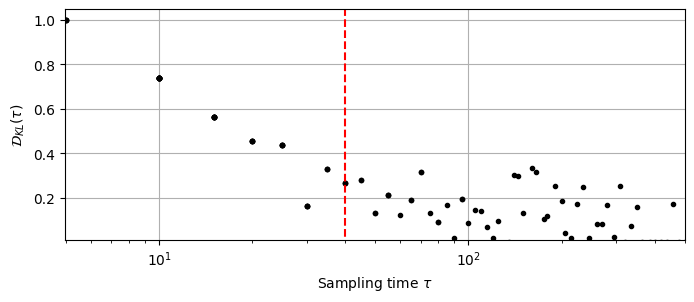

In [ ]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([utils.markov_test(data[loc_idx], delta, N=32) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, kl_div.max()+0.05])
plt.grid()

In [ ]:
## Kramers-Moyal average
stride = stride_coarse
f_KM, a_KM, f_err, a_err = KM_avg(data, bins, stride=stride, dt=dt, multi_traj=True)

/tmp/ipykernel_28078/156247817.py:39: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=1)
/tmp/ipykernel_28078/156247817.py:40: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=1)
/tmp/ipykernel_28078/156247817.py:41: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=1)
/tmp/ipykernel_28078/156247817.py:42: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=1)


In [ ]:
### Build SINDy libraries with sympy
x = sympy.symbols('x')

f_expr = np.array([x**i for i in np.arange(5)])  # Polynomial library for drift
s_expr = np.array([x**i for i in np.arange(4)])  # Polynomial library for diffusion

# Convert sympy expressions into library matrices
lib_f = np.zeros([len(f_expr), N])
for k in range(len(f_expr)):
    lamb_expr = sympy.lambdify(x, f_expr[k])
    lib_f[k] = lamb_expr(centers)

lib_s = np.zeros([len(s_expr), N])
for k in range(len(s_expr)):
    lamb_expr = sympy.lambdify(x, s_expr[k])
    lib_s[k] = lamb_expr(centers)

In [ ]:
# Initialize Xi with least squares regression (no finite-time corrections)

Xi0 = np.zeros((len(f_expr) + len(s_expr)))
mask = np.nonzero(np.isfinite(f_KM))[0]
Xi0[:len(f_expr)] = np.linalg.lstsq( lib_f[:, mask].T, f_KM[mask], rcond=None)[0]   # Regression against drift
Xi0[len(f_expr):] = np.linalg.lstsq( lib_s[:,mask].T, np.sqrt(2*a_KM[mask]), rcond=None)[0]  # Regression against diffusion

print(Xi0)

[-1.50636211e-02 -9.82322871e-03  7.00718835e-04  1.36310162e-05
 -1.92510328e-06  6.19749658e-01 -1.40712710e-02  5.35329664e-04
 -1.88216807e-05]


In [ ]:
### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.flatten(), a_err.flatten()))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())

# Compute empirical PDF
p_hist = np.histogram(np.concatenate(data), bins, density=True)[0]

# Initialize adjoint solver
afp = fpsolve.AdjFP(centers)

# Initialize forward steady-state solver
fp = fpsolve.SteadyFP(N, dx)

# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f.T, "lib_s": lib_s.T, "N": N,
          "kl_reg": 10,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

# Use anonymous function to automatically pass the cost function
opt_fun = lambda params: utils.AFP_opt(cost, params)
Xi, V = utils.SSR_loop(opt_fun, params)

%%%% Optimization time: 33.545063734054565 seconds,   Cost: 0.05702165155892982 %%%%
[1 2 3 4]
[0 1 2 3]
[x x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 21.218793392181396 seconds,   Cost: 0.1142714954516611 %%%%
[0 2 3 4]
[0 1 2 3]
[1 x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 18.97722840309143 seconds,   Cost: 0.16850981813814558 %%%%
[0 1 3 4]
[0 1 2 3]
[1 x x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 24.99351739883423 seconds,   Cost: 0.10658393997534304 %%%%
[0 1 2 4]
[0 1 2 3]
[1 x x**2 x**4] [1 x x**2 x**3]
%%%% Optimization time: 36.81956672668457 seconds,   Cost: 0.057484742944895084 %%%%
[0 1 2 3]
[0 1 2 3]
[1 x x**2 x**3] [1 x x**2 x**3]
%%%% Optimization time: 15.4034423828125 seconds,   Cost: 0.16240154320877168 %%%%
[0 1 2 3 4]
[1 2 3]
[1 x x**2 x**3 x**4] [x x**2 x**3]
%%%% Optimization time: 18.964484691619873 seconds,   Cost: 21.932064892928224 %%%%
[0 1 2 3 4]
[0 2 3]
[1 x x**2 x**3 x**4] [1 x**2 x**3]
%%%% Optimization time: 21.09247994

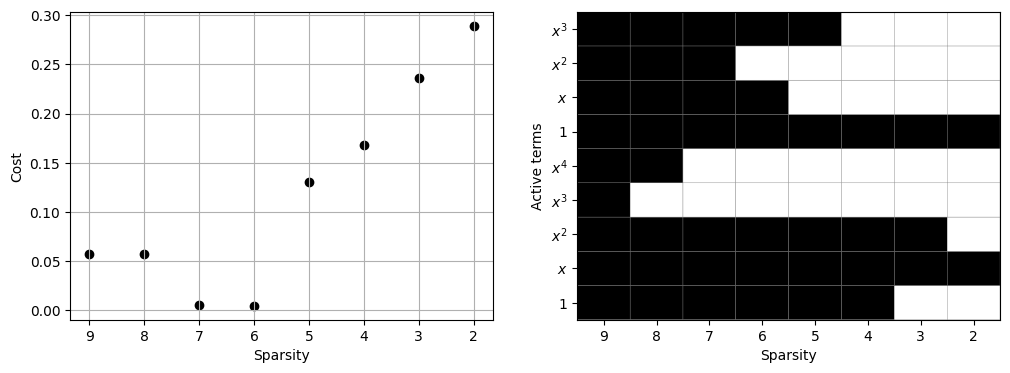

In [ ]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(np.arange(len(V)), V, c='k')

plt.gca().set_xticks(np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
#plt.gca().set_yscale('log')
plt.grid()

plt.subplot(122)
plt.pcolor(active, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(n_terms))
plt.gca().set_yticklabels(labels)
plt.gca().set_xticks(0.5+np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel('Active terms')
plt.show()

In [ ]:
# Select model with the fewest terms before the cost function spikes
n_terms = 6
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V[1-n_terms])
Xi_f = Xi[:len(f_expr), 1-n_terms]
Xi_s = Xi[len(f_expr):, 1-n_terms]
print("Basis functions (drift): ", f_expr)
print("SINDy expression (drift): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f])
print("Base functions (diffusion): ", s_expr)
print("SINDy expression (diffusion): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s])

# Functions from the expressions
f_sindy = sympy.lambdify(x, utils.sindy_model(Xi_f, f_expr))
a_sindy = sympy.lambdify(x, 0.5*utils.sindy_model(Xi_s, s_expr)**2)

f_vals = f_sindy(centers)
a_vals = a_sindy(centers)

# Check if a scalar (happens when library is a constant)
if np.isscalar(a_vals):
    a_vals = a_vals + 0*centers
if np.isscalar(f_vals):
    f_vals = f_vals + 0*centers

Optimal sparsity:  6
Cost at optimal sparsity:  0.004633387244422943
Basis functions (drift):  [1 x x**2 x**3 x**4]
SINDy expression (drift):  ['-8.778E-03', '-1.094E-02', '6.279E-04', '0', '0']
Base functions (diffusion):  [1 x x**2 x**3]
SINDy expression (diffusion):  ['6.292E-01', '-2.157E-02', '0', '-3.954E-05']


KL divergence (LINDy model): -0.01666


(-0.01, 0.11)

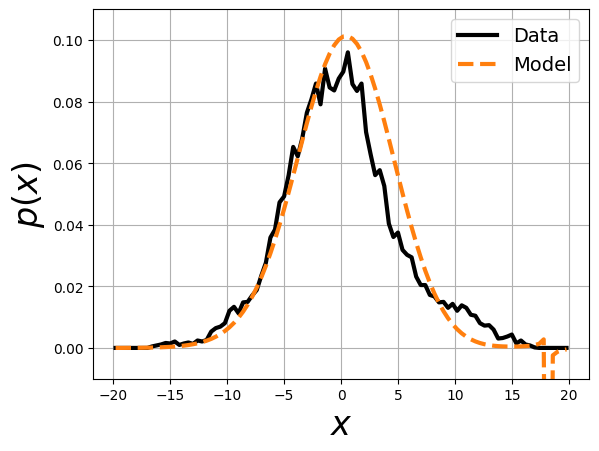

In [ ]:
# Compare PDFs: empirical vs Fokker-Planck solution with model

p_fit = fp.solve(f_vals, a_vals)
print('KL divergence (LINDy model): {0:0.5f}'.format(utils.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

#plt.figure(figsize=(4, 2))
plt.plot(centers, p_hist, 'k', label='Data', lw=3)
plt.plot(centers, p_fit, '--', c=colors[1], label='Model', lw=3)
plt.legend(fontsize=14)
#plt.gca().set_yscale('log')
#plt.xlim([0, 3])
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$p(x)$', fontsize = 24)
plt.grid()
plt.ylim([-1e-2,0.11])

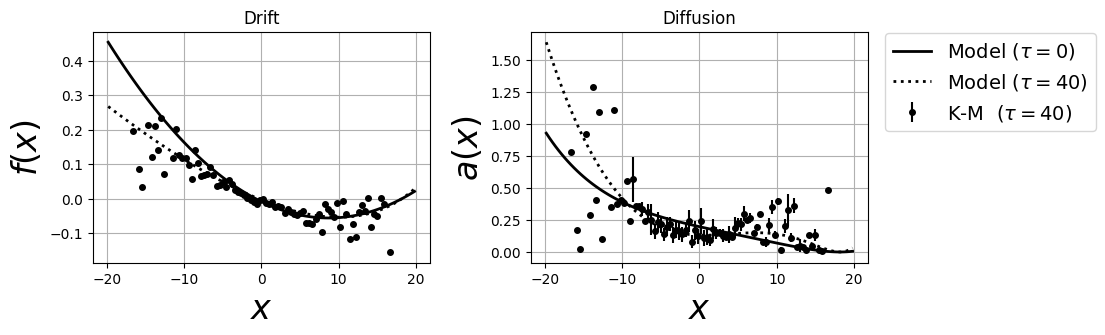

In [ ]:
afp.precompute_operator(f_vals, a_vals)
f_tau, a_tau = afp.solve(stride*dt)

plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.errorbar(centers, f_KM, f_err, ls='', marker='.', markersize=8, 
             c='k')
plt.plot(centers, f_vals, 'k', lw=2)
plt.plot(centers, f_tau, 'k:', lw=2)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()
#plt.xlim([-1.8, 1.8])
#plt.ylim([-1, 0.3])


plt.subplot(122)
plt.errorbar(centers, a_KM, a_err, ls='', marker='.', markersize=8, 
             c='k', label=r'K-M  ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.plot(centers, a_vals, 'k', lw=2, label=r'Model ($\tau = 0$)')
plt.plot(centers, a_tau, 'k:', lw=2, label=r'Model ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()
# plt.xlim([-1.8, 1.8])
#plt.ylim([0, 2.25])

plt.subplots_adjust(wspace=0.3)
plt.show()

Text(0.5, 0, '$x$')

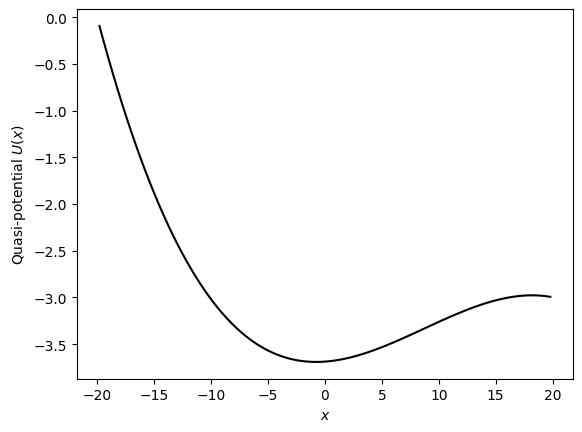

In [ ]:
def U(x):
    h=0.1
    num = np.round((x-bins[0])/h).astype(int)
    xvec = np.linspace(bins[0],x,num)
    return -np.trapz(f_sindy(xvec), xvec)

Uvec = np.zeros(centers.shape[0])
for i in range(centers.shape[0]):
    Uvec[i] = U(centers[i])

plt.plot(centers, Uvec, 'k-')
plt.ylabel('Quasi-potential $U(x)$')
plt.xlabel('$x$')

### All trajectories together

/tmp/ipykernel_28078/156247817.py:39: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=1)
/tmp/ipykernel_28078/156247817.py:40: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=1)
/tmp/ipykernel_28078/156247817.py:41: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=1)
/tmp/ipykernel_28078/156247817.py:42: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=1)


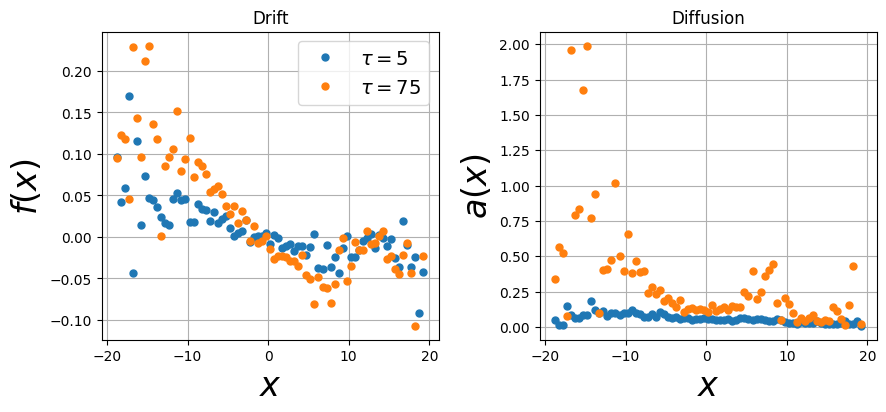

In [ ]:
# Langevin regression on first PC mode

# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

N = 100 # Number of bins
bins = np.linspace(-25,25, N+1)
dx = bins[1]-bins[0]
centers = (bins[:-1]+bins[1:])/2

data = [X_t[i,:,0] for i in range(num_loc)] # high flow data, pass as list into KM_avg

f_fine, a_fine, _,_ = KM_avg(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=15
f_coarse, a_coarse, _,_ = KM_avg(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(centers, f_fine, '.', markersize=10, c=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.plot(centers, f_coarse, '.', markersize=10, c=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.plot(centers, a_fine, '.', c=colors[0], markersize=10)
plt.plot(centers, a_coarse, '.', c=colors[1], markersize=10)
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

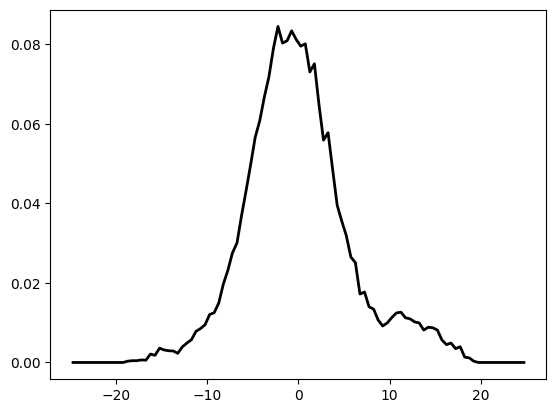

In [ ]:
# PDF of states

p_hist = np.histogram(np.concatenate(data), bins, density=True)[0]
plt.plot(centers, p_hist, 'k', lw=2)

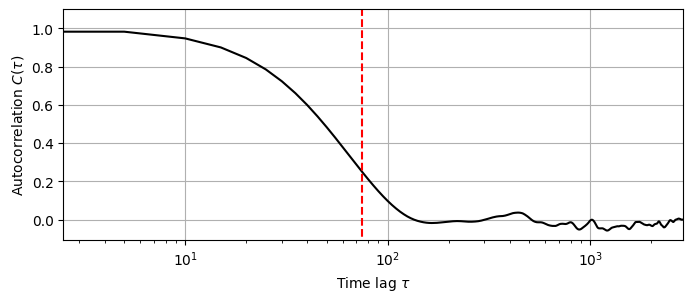

In [ ]:
tau = dt*np.arange(0, len(data[0]))
acf = np.zeros(len(tau))
for loc_idx in range(num_loc):
    acf = acf + utils.autocorr_func_1d(data[loc_idx])
acf = acf/num_loc

plt.figure(figsize=(8, 3))
plt.plot(tau, acf, 'k')

plt.ylabel(r'Autocorrelation $C(\tau)$')
plt.xlabel(r'Time lag $\tau$')
plt.vlines(stride_coarse*dt, -0.6, 1.1, 'r', '--')

plt.ylim([acf.min()-0.05, 1.1])
plt.xlim([0.5*dt, tau.max()])
plt.gca().set_xscale('log')

plt.grid()
plt.show()


/home/erin.angelini/my-envs/hcs-env/lib/python3.11/site-packages/numpy/lib/histograms.py:1067: RuntimeWarning: invalid value encountered in divide
  hist /= s
/home/erin.angelini/my-envs/hcs-env/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


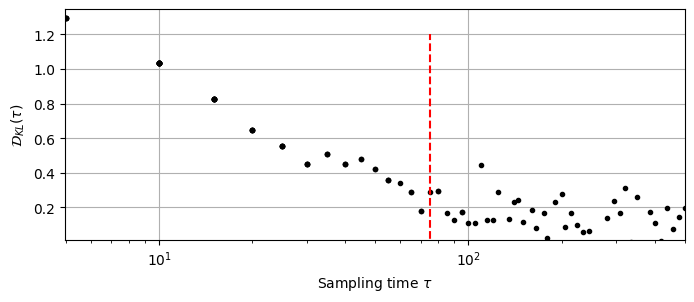

In [ ]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([utils.markov_test(data[loc_idx], delta, N=32) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, kl_div.max()+0.05])
plt.grid()

In [ ]:
## Kramers-Moyal average
stride = stride_coarse
f_KM, a_KM, f_err, a_err = KM_avg(data, bins, stride=stride, dt=dt, multi_traj=True)

/tmp/ipykernel_28078/156247817.py:39: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=1)
/tmp/ipykernel_28078/156247817.py:40: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=1)
/tmp/ipykernel_28078/156247817.py:41: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=1)
/tmp/ipykernel_28078/156247817.py:42: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=1)


In [ ]:
### Build SINDy libraries with sympy
x = sympy.symbols('x')

f_expr = np.array([x**i for i in np.arange(5)])  # Polynomial library for drift
s_expr = np.array([x**i for i in np.arange(4)])  # Polynomial library for diffusion

# Convert sympy expressions into library matrices
lib_f = np.zeros([len(f_expr), N])
for k in range(len(f_expr)):
    lamb_expr = sympy.lambdify(x, f_expr[k])
    lib_f[k] = lamb_expr(centers)

lib_s = np.zeros([len(s_expr), N])
for k in range(len(s_expr)):
    lamb_expr = sympy.lambdify(x, s_expr[k])
    lib_s[k] = lamb_expr(centers)

In [ ]:
# Initialize Xi with least squares regression (no finite-time corrections)

Xi0 = np.zeros((len(f_expr) + len(s_expr)))
mask = np.nonzero(np.isfinite(f_KM))[0]
Xi0[:len(f_expr)] = np.linalg.lstsq( lib_f[:, mask].T, f_KM[mask], rcond=None)[0]   # Regression against drift
Xi0[len(f_expr):] = np.linalg.lstsq( lib_s[:,mask].T, np.sqrt(2*a_KM[mask]), rcond=None)[0]  # Regression against diffusion

print(Xi0)

[-1.73629273e-02 -7.27973247e-03  6.74232991e-04  9.04400516e-06
 -1.52793361e-06  6.21781587e-01 -2.13699450e-02  7.23395076e-04
 -8.39685566e-06]


In [ ]:
### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.flatten(), a_err.flatten()))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())

# Compute empirical PDF
p_hist = np.histogram(np.concatenate(data), bins, density=True)[0]

# Initialize adjoint solver
afp = fpsolve.AdjFP(centers)

# Initialize forward steady-state solver
fp = fpsolve.SteadyFP(N, dx)

# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f.T, "lib_s": lib_s.T, "N": N,
          "kl_reg": 10,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

# Use anonymous function to automatically pass the cost function
opt_fun = lambda params: utils.AFP_opt(cost, params)
Xi, V = utils.SSR_loop(opt_fun, params)

%%%% Optimization time: 33.04624915122986 seconds,   Cost: 0.06693898891192332 %%%%
[1 2 3 4]
[0 1 2 3]
[x x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 151.1593780517578 seconds,   Cost: 0.1479493845974039 %%%%
[0 2 3 4]
[0 1 2 3]
[1 x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 51.1949188709259 seconds,   Cost: 0.18398768537124574 %%%%
[0 1 3 4]
[0 1 2 3]
[1 x x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 60.75322508811951 seconds,   Cost: 0.1931835401654628 %%%%
[0 1 2 4]
[0 1 2 3]
[1 x x**2 x**4] [1 x x**2 x**3]
%%%% Optimization time: 16.546863079071045 seconds,   Cost: 0.059276450741334585 %%%%
[0 1 2 3]
[0 1 2 3]
[1 x x**2 x**3] [1 x x**2 x**3]
%%%% Optimization time: 32.11400127410889 seconds,   Cost: 0.27481976640679884 %%%%
[0 1 2 3 4]
[1 2 3]
[1 x x**2 x**3 x**4] [x x**2 x**3]
%%%% Optimization time: 25.59030270576477 seconds,   Cost: 44.516991744789216 %%%%
[0 1 2 3 4]
[0 2 3]
[1 x x**2 x**3 x**4] [1 x**2 x**3]
%%%% Optimization time: 32.35302567481

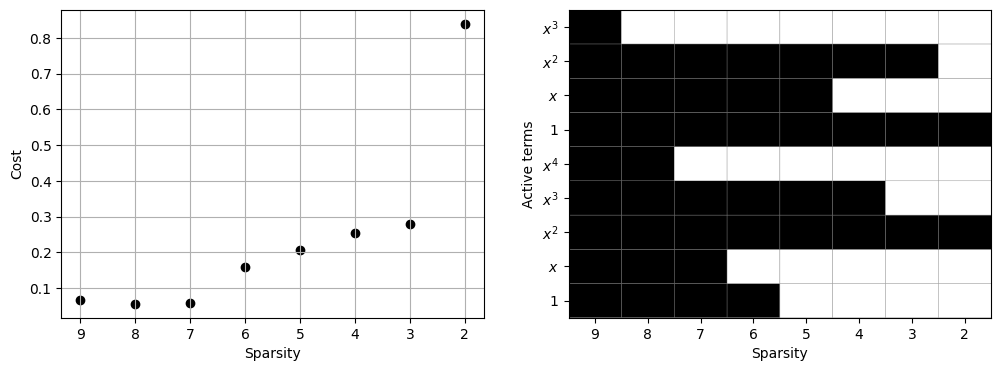

In [ ]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(np.arange(len(V)), V, c='k')

plt.gca().set_xticks(np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
#plt.gca().set_yscale('log')
plt.grid()

plt.subplot(122)
plt.pcolor(active, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(n_terms))
plt.gca().set_yticklabels(labels)
plt.gca().set_xticks(0.5+np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel('Active terms')
plt.show()

In [ ]:
# Select model with the fewest terms before the cost function spikes
n_terms = 7
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V[1-n_terms])
Xi_f = Xi[:len(f_expr), 1-n_terms]
Xi_s = Xi[len(f_expr):, 1-n_terms]
print("Basis functions (drift): ", f_expr)
print("SINDy expression (drift): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f])
print("Base functions (diffusion): ", s_expr)
print("SINDy expression (diffusion): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s])

# Functions from the expressions
f_sindy = sympy.lambdify(x, utils.sindy_model(Xi_f, f_expr))
a_sindy = sympy.lambdify(x, 0.5*utils.sindy_model(Xi_s, s_expr)**2)

f_vals = f_sindy(centers)
a_vals = a_sindy(centers)

# Check if a scalar (happens when library is a constant)
if np.isscalar(a_vals):
    a_vals = a_vals + 0*centers
if np.isscalar(f_vals):
    f_vals = f_vals + 0*centers

Optimal sparsity:  7
Cost at optimal sparsity:  0.058862344560868
Basis functions (drift):  [1 x x**2 x**3 x**4]
SINDy expression (drift):  ['-5.046E-02', '-5.312E-03', '1.747E-03', '-8.127E-05', '0']
Base functions (diffusion):  [1 x x**2 x**3]
SINDy expression (diffusion):  ['6.721E-01', '-5.974E-02', '2.348E-03', '0']


KL divergence (LINDy model): 0.00537


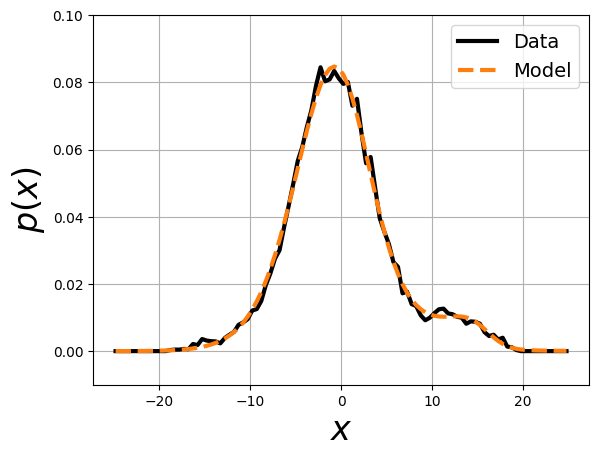

In [ ]:
# Compare PDFs: empirical vs Fokker-Planck solution with model

p_fit = fp.solve(f_vals, a_vals)
print('KL divergence (LINDy model): {0:0.5f}'.format(utils.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

#plt.figure(figsize=(4, 2))
plt.plot(centers, p_hist, 'k', label='Data', lw=3)
plt.plot(centers, p_fit, '--', c=colors[1], label='Model', lw=3)
plt.legend(fontsize=14)
#plt.gca().set_yscale('log')
plt.ylim([-1e-2, 0.1])
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$p(x)$', fontsize = 24)
plt.grid()

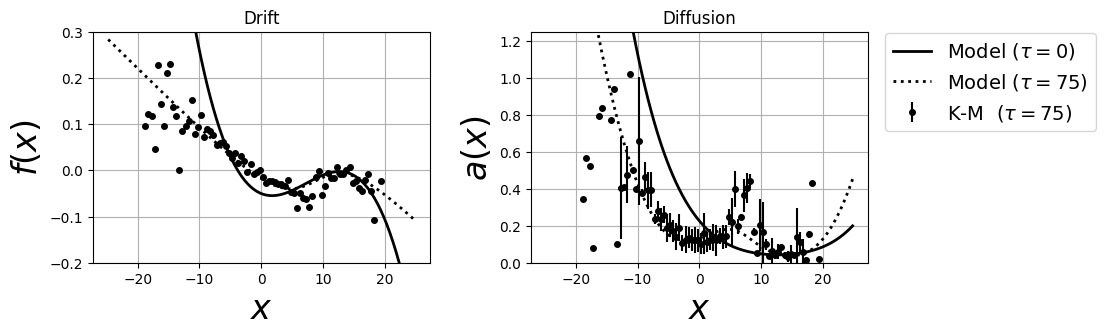

In [ ]:
afp.precompute_operator(f_vals, a_vals)
f_tau, a_tau = afp.solve(stride*dt)

plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.errorbar(centers, f_KM, f_err, ls='', marker='.', markersize=8, 
             c='k')
plt.plot(centers, f_vals, 'k', lw=2)
plt.plot(centers, f_tau, 'k:', lw=2)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()
#plt.xlim([-1.8, 1.8])
plt.ylim([-0.2, 0.3])


plt.subplot(122)
plt.errorbar(centers, a_KM, a_err, ls='', marker='.', markersize=8, 
             c='k', label=r'K-M  ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.plot(centers, a_vals, 'k', lw=2, label=r'Model ($\tau = 0$)')
plt.plot(centers, a_tau, 'k:', lw=2, label=r'Model ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()
# plt.xlim([-1.8, 1.8])
plt.ylim([0, 1.25])

plt.subplots_adjust(wspace=0.3)
plt.show()

Text(0.5, 0, '$x$')

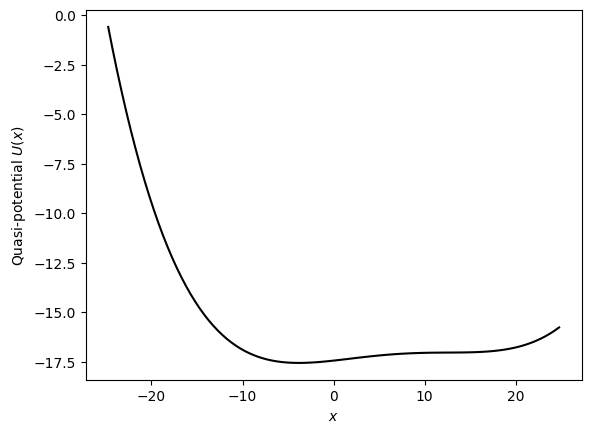

In [ ]:
def U(x):
    h=0.1
    num = np.round((x-bins[0])/h).astype(int)
    xvec = np.linspace(bins[0],x,num)
    return -np.trapz(f_sindy(xvec), xvec)

Uvec = np.zeros(centers.shape[0])
for i in range(centers.shape[0]):
    Uvec[i] = U(centers[i])

plt.plot(centers, Uvec, 'k-')
plt.ylabel('Quasi-potential $U(x)$')
plt.xlabel('$x$')

## Bifurcation analysis ([Freedman <i>et al.</i> 2023)](https://doi.org/10.1242/dev.201280))

From "Analysis Pipeline" section of paper:
1. Obtain highly sampled temporal data.
2. Bin the data along the temporal axis.
3. Compute the largest eigenvalue of the covariance matrix ($\omega_1$) in each bin (e.g. using an off-the-shelf PCA function).
4. Evaluate whether a bifurcation occurs by comparing $\omega_1$ with a suitable null (see [Appendix S1](https://journals.biologists.com/Toolbox/DownloadCombinedArticleAndSupplmentPdf?resourceId=312613&multimediaId=2900265&pdfUrl=%2Fcob%2Fcontent_public%2Fjournal%2Fdev%2F150%2F11%2F10.1242_dev.201280%2F2%2Fdev201280.pdf), section 4): spike indicates a one-to-one bifurcation; steady increase indicates a one-to-many bifurcation.
5. If a bifurcation is detected (e.g. at $\tau_c$), compute and examine the principal covariance eigenvector at $\tau$, as it reflects mechanistic aspects of the underlying dynamical system.

In [379]:
bin_width=6 # number of timepoints to bin together
bins = np.arange(0,num_t,bin_width)
N = len(bins)-1
centers = (bins[:-1]+bins[1:])/2

In [380]:
omega1 = np.zeros(N)
v1 = np.zeros((num_modes_95,N))

n_s = 20 # null sampling
omega1_null = np.zeros((N,n_s))

for i in range(N):
    data_binned = X_t[:,bins[i]:bins[i+1],:].reshape(-1,num_modes_95)
    C = np.cov(data_binned.T)
    omega, v = np.linalg.eigh(C)
    omega1[i] = omega.max()
    v1[:,i] = v[:,omega.argmax()]

    for j in range(n_s):
        null_mat = np.zeros((num_loc,num_modes_95))
        for jj in range(num_modes_95):
            null_mat[:,jj] = np.random.choice(data_binned[:,jj],size=num_loc)
        C_null = np.cov(null_mat.T)
        omega_null = np.linalg.eigvalsh(C_null)
        omega1_null[i,j] = omega_null.max()

    

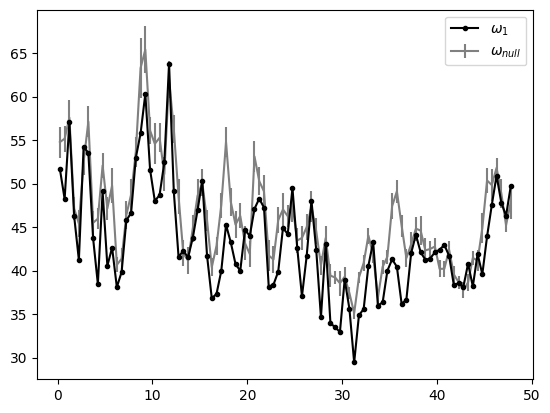

In [388]:
plt.plot(5*centers/60,omega1,'k-',marker='.',zorder=10,label='$\omega_1$')
plt.errorbar(5*centers/60,omega1_null.mean(axis=-1),yerr=omega1_null.std(axis=-1)/np.sqrt(n_s),color='gray',ecolor='gray',label='$\omega_{null}$')
plt.legend()

## Control parameter: flow rate

In [367]:
t_vec = np.arange(num_t)
u = (20-6)*(1-np.heaviside(t_vec-num_t//2,1/2)) + 6

(0.0, 21.0)

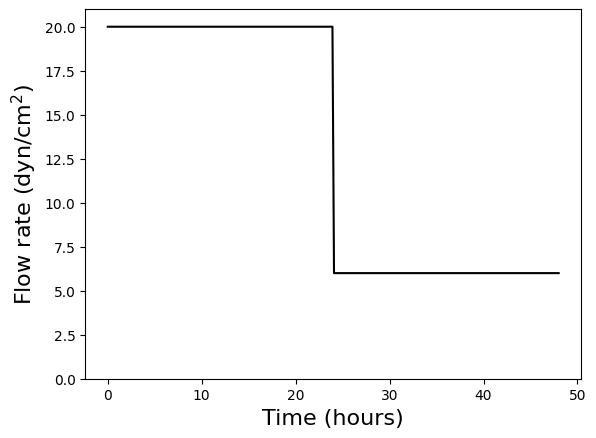

In [386]:
plt.plot(5*t_vec/60,u,'k-')
plt.xlabel("Time (hours)",fontsize=16)
plt.ylabel("Flow rate (dyn/$\\text{cm}^2$)",fontsize=16)
plt.ylim([0,21])